# Session 10

1-Cross-validation approachs:

 1- Holdout validation (Train_test_split) : this include stratification( Stratified Cross-Validation)

 2-LOOCV ( Leave One out cross validation) :In this method the model is trained on the entire dataset except for one data point which is used for testing. This process is repeated for each data point in the dataset. - obviously no stratified

 3-K-Fold cross validation : splits the dataset into k equal-sized folds. The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times each time using a different fold for testing. :  stratified 

 Data split into 10 equal folds: [F1][F2][F3][F4][F5][F6][F7][F8][F9][F10]

Iteration 1:  Train = F2-F10,  Test = F1  → Score 1

Iteration 2:  Train = F1,F3-F10, Test = F2  → Score 2

Iteration 3:  Train = F1-F2,F4-F10, Test = F3  → Score 3
...

Iteration 10: Train = F1-F9,   Test = F10 → Score 10

Total: 10 iterations, 10 scores, 10 different test folds


4- Repeated K-fold cross validation : 
RepeatedKFold(K=5, repeats=3):

[Shuffle 1]  Fold1 Fold2 Fold3 Fold4 Fold5  → 5 scores

[Shuffle 2]  Fold1 Fold2 Fold3 Fold4 Fold5  → 5 scores  (different splits!)

[Shuffle 3]  Fold1 Fold2 Fold3 Fold4 Fold5  → 5 scores

Total: 15 scores → Average → Final performance


5- LeavePOut
LeaveOneOut: Test 1 sample, repeat n times

LeavePOut:   Test P samples, repeat C(n,P) times

LeavePOut grows FACTORIALLY — almost never used in practice.

LOO is already slow enough for most cases.

------------------------------------------

2- Logistic Regression (an approach for classification)
It is used (usally) for binary classification where the output can be one of two possible categories such as Yes/No, True/False or 0/1.
types : 

Binomial 

multinomial 


ordinal 

what thereshould does : model.predict_prob(X)> thre ---> 1 else 0

-----------------












In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, LeaveOneOut, LeavePOut, StratifiedKFold, train_test_split, cross_validate, cross_val_score

## Cross validation

In [14]:
X = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

In [18]:
#KFold
kf = KFold(n_splits = 3)
for data in kf.split(X):
    print (data) #index

kf.split(X)

(array([ 4,  5,  6,  7,  8,  9, 10, 11]), array([0, 1, 2, 3]))
(array([ 0,  1,  2,  3,  8,  9, 10, 11]), array([4, 5, 6, 7]))
(array([0, 1, 2, 3, 4, 5, 6, 7]), array([ 8,  9, 10, 11]))


<generator object _BaseKFold.split at 0x0000023AA1250160>

In [21]:
#LeaveOneOut
loo = LeaveOneOut()
for data in loo.split(X):
    print(data)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([0]))
(array([ 0,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([1]))
(array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([2]))
(array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 11]), array([3]))
(array([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11]), array([4]))
(array([ 0,  1,  2,  3,  4,  6,  7,  8,  9, 10, 11]), array([5]))
(array([ 0,  1,  2,  3,  4,  5,  7,  8,  9, 10, 11]), array([6]))
(array([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11]), array([7]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  9, 10, 11]), array([8]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11]), array([9]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11]), array([10]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([11]))


In [23]:
#Lpo
lpo = LeavePOut(p=3)
sum = 0 
for data in lpo.split(X):
    print(data)
    sum += 1

sum


(array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]), array([0, 1, 2]))
(array([ 2,  4,  5,  6,  7,  8,  9, 10, 11]), array([0, 1, 3]))
(array([ 2,  3,  5,  6,  7,  8,  9, 10, 11]), array([0, 1, 4]))
(array([ 2,  3,  4,  6,  7,  8,  9, 10, 11]), array([0, 1, 5]))
(array([ 2,  3,  4,  5,  7,  8,  9, 10, 11]), array([0, 1, 6]))
(array([ 2,  3,  4,  5,  6,  8,  9, 10, 11]), array([0, 1, 7]))
(array([ 2,  3,  4,  5,  6,  7,  9, 10, 11]), array([0, 1, 8]))
(array([ 2,  3,  4,  5,  6,  7,  8, 10, 11]), array([0, 1, 9]))
(array([ 2,  3,  4,  5,  6,  7,  8,  9, 11]), array([ 0,  1, 10]))
(array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]), array([ 0,  1, 11]))
(array([ 1,  4,  5,  6,  7,  8,  9, 10, 11]), array([0, 2, 3]))
(array([ 1,  3,  5,  6,  7,  8,  9, 10, 11]), array([0, 2, 4]))
(array([ 1,  3,  4,  6,  7,  8,  9, 10, 11]), array([0, 2, 5]))
(array([ 1,  3,  4,  5,  7,  8,  9, 10, 11]), array([0, 2, 6]))
(array([ 1,  3,  4,  5,  6,  8,  9, 10, 11]), array([0, 2, 7]))
(array([ 1,  3,  4,  5,  6,  7,  9

220

In [27]:
from math import comb
comb(12,3)

220

In [40]:
#StratifiedKFold
skf = skf = StratifiedKFold(n_splits=3)
for data in skf.split(X,y):
    print(data)

(array([ 2,  3,  4,  5,  8,  9, 10, 11]), array([0, 1, 6, 7]))
(array([ 0,  1,  4,  5,  6,  7, 10, 11]), array([2, 3, 8, 9]))
(array([0, 1, 2, 3, 6, 7, 8, 9]), array([ 4,  5, 10, 11]))


In [51]:
# train model
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import f1_score

model = RandomForestClassifier()


for train_idx, test_idx in skf.split(X, y):
    x_train = X[train_idx].reshape(-1, 1)
    y_train = y[train_idx]
    
    x_test = X[test_idx].reshape(-1, 1)   # reshape test data too
    y_test = y[test_idx]
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)         # predict on UNSEEN data
    
    score = f1_score(y_test, y_pred)       # (true, predicted)
    print(score)

0.6666666666666666
1.0
0.8


Cross validate s Cross _val_score

Cross-val-score:

cross_val_score(

    estimator,          # Model (e.g., LogisticRegression())
    X, y,               # Data
    cv=5,               # Number of folds or splitter object
    scoring='accuracy', # Metric: 'accuracy','precision','recall','f1','roc_auc', etc.
    n_jobs=-1,          # CPU cores (-1 = all)
    verbose=0,          # 0=silent, 1=progress, 2=details
    error_score='raise' # 'raise' or float (return this if error)
)




cross_validate(

    estimator,              # Model
    X, y,                   # Data
    cv=5,                   # Folds
    scoring=all metrics you want,           # Single string, list of strings, or dict
    n_jobs=-1,              # CPU cores
    verbose=0,              # Verbosity
    return_train_score=True,# Include train scores? (default=False)
    return_estimator=False, # Return fitted models?
    error_score='raise'     # 'raise' or np.nan
)

In [60]:
import numpy as np
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Sample data
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

# Fix: Reshape X to 2D
X = X.reshape(-1, 1)

# Model
model = RandomForestClassifier(random_state=42)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Cross-validate
results = cross_validate(
    model,
    X, y,
    cv=skf,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=True,
    verbose=2
)

print("Test Accuracy:", results['test_accuracy'].mean())
print("Test F1:      ", results['test_f1'].mean())
print("Train Accuracy:", results['train_accuracy'].mean())

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
Test Accuracy: 0.9166666666666666
Test F1:       0.9333333333333332
Train Accuracy: 1.0


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.5s finished


## Logistic Regression

In [61]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
import matplotlib.pyplot as plt

In [62]:
X = np.array([3,5,6,8,22,28,29,31,78,80,81,83]).reshape(-1,1)
y = np.array([0,0,0,0,1,1,1,1,2,2,2,2])

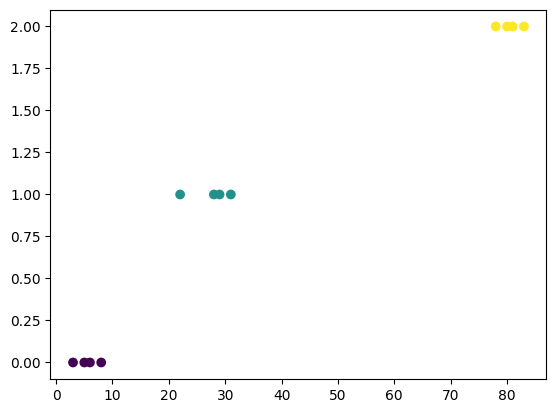

In [63]:
plt.scatter(X,y,c=y)

In [64]:
model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)
y_pred[y_pred < 0.5] = 0
y_pred[y_pred >= 0.5] = 1


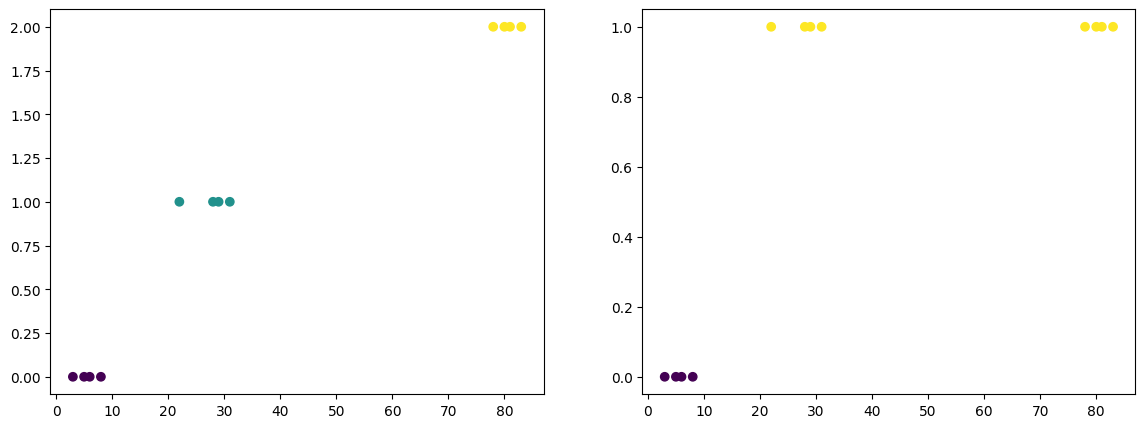

In [65]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.scatter(X,y, c=y)

plt.subplot(1,2,2)
plt.scatter(X,y_pred,c=y_pred)

In [66]:
print(y)
print(y_pred)

[0 0 0 0 1 1 1 1 2 2 2 2]
[0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


In [67]:
model = LogisticRegression()
model.fit(X,y)

model.predict(X)

# precision, recall, f1_score, accuracy

array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2])

## Implementing on Mnist - GPU vs CPU

In [72]:
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
#X,y = fetch_openml('mnist_784',as_frame = False, return_X_y = True)

In [77]:
df = pd.read_csv("mnist_784.csv")
df

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [80]:
X = df.drop(columns=['class']).values  # Features (784 pixels)
y = df['class'].values 
print(X)
y

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


array([5, 0, 4, ..., 4, 5, 6], dtype=int64)

In [82]:
X.shape

(70000, 784)

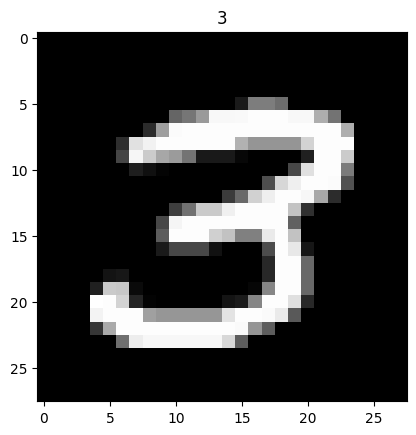

In [92]:
n = 179
plt.title(y[n])
plt.imshow(X[n].reshape(28,28),cmap='gray')

In [93]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [94]:
model = LogisticRegression(max_iter=300)

model.fit(x_train, y_train)

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [95]:
y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.96      0.97      0.96      1575
           2       0.90      0.90      0.90      1398
           3       0.89      0.88      0.89      1428
           4       0.93      0.92      0.92      1365
           5       0.88      0.85      0.87      1263
           6       0.93      0.96      0.95      1375
           7       0.93      0.93      0.93      1459
           8       0.88      0.85      0.87      1365
           9       0.88      0.90      0.89      1391

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



<Axes: >

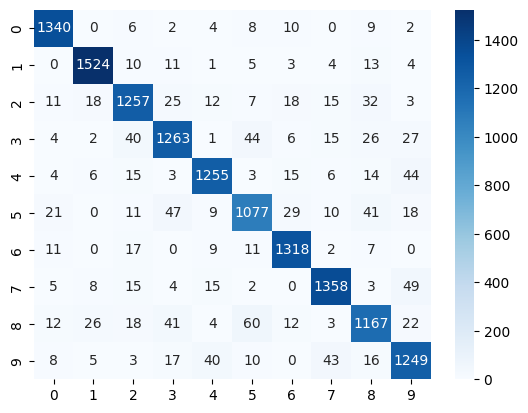

In [96]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")

In [100]:
X, y = load_digits(return_X_y=True, as_frame=False)
X.shape

(1797, 64)

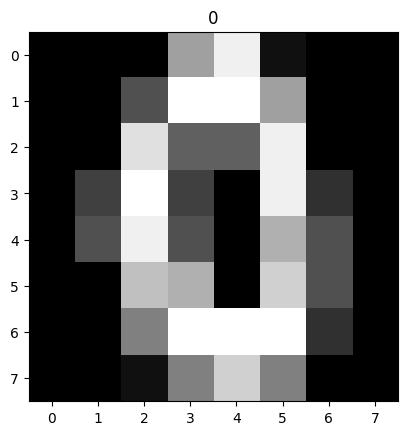

In [101]:
n = 179

plt.title(str(y[n]))
plt.imshow(X[n].reshape((8, 8)), cmap='gray')

In [102]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [103]:
model = LogisticRegression(max_iter=300)

model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [104]:
y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.88      0.97      0.92        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       1.00      0.97      0.99        36
           5       0.92      0.89      0.90        37
           6       0.97      1.00      0.99        36
           7       0.97      0.94      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.97      0.97        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



<Axes: >

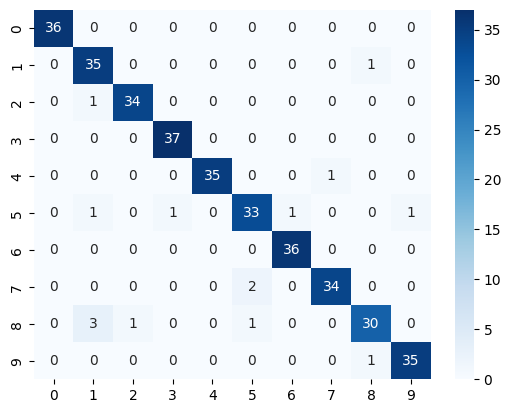

In [105]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")

### Learning curve - manually

[0.965, 0.9666666666666667, 0.9666666666666667, 0.975, 0.95, 0.9722222222222222]


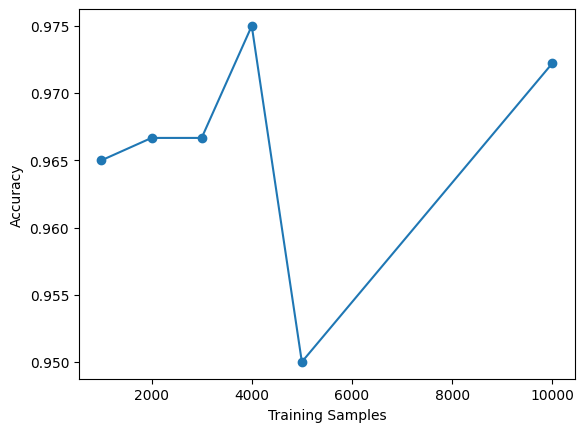

In [115]:
n_samples = [1000, 2000, 3000, 4000, 5000, 10000]
accuracies = []

for n_sample in n_samples:
    x_train, x_test, y_train, y_test = train_test_split(X[:n_sample], y[:n_sample], test_size=0.2, shuffle=True, stratify=y[:n_sample])

    model = LogisticRegression(max_iter=300)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)



    accuracies.append(accuracy_score(y_test, y_pred))

    


print(accuracies)

plt.plot(n_samples, accuracies, 'o-')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy')
plt.show()


## Manual (your way)
# Run 1: 0.82 → Run 2: 0.87 → Run 3: 0.84
# Inconsistent! Depends on lucky split.

# sklearn learning_curve
# 0.85 ± 0.02 (mean ± std across 5 folds)
# Reliable! Shows true performance range.

Train: 1% (17 samples) — Accuracy: 0.7663
Train: 2% (35 samples) — Accuracy: 0.8246
Train: 3% (53 samples) — Accuracy: 0.8595
Train: 4% (71 samples) — Accuracy: 0.8673
Train: 5% (89 samples) — Accuracy: 0.9028
Train: 10% (179 samples) — Accuracy: 0.9302
Train: 20% (359 samples) — Accuracy: 0.9471


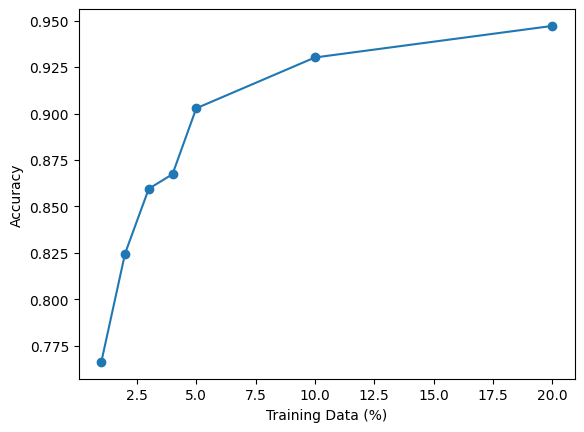

In [117]:
n_samples = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2]
accuracies = []

for n_sample in n_samples:
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, train_size=n_sample, shuffle=True, stratify=y
    )
    
    model = LogisticRegression(max_iter=300)
    model.fit(x_train, y_train)
    
    # Predict on SAME test set you evaluate on!
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    
    print(f"Train: {n_sample:.0%} ({len(x_train)} samples) — Accuracy: {accuracy:.4f}")

plt.plot([s*100 for s in n_samples], accuracies, 'o-')
plt.xlabel('Training Data (%)')
plt.ylabel('Accuracy')
plt.show()

### Sklearn learning curve

In [120]:
lc = learning_curve(
    model,
    X,y,
    train_sizes=[0.1,0.2,0.3,0.4,0.5],
    scoring="accuracy",
    verbose=True
)



#5 sizes × 5 folds = 25 trainings

#Size 10% (143): 5 folds → 5 trainings
#Size 20% (287): 5 folds → 5 trainings
#Size 30% (431): 5 folds → 5 trainings
#Size 40% (574): 5 folds → 5 trainings
#Size 50% (718): 5 folds → 5 trainings

#Total: 5 + 5 + 5 + 5 + 5 = 25

[learning_curve] Training set sizes: [143 287 431 574 718]


[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    2.4s finished


In [121]:
lc

#What It Returns

#train_sizes, train_scores, test_scores = learning_curve(...)

# train_sizes: [700, 1400, 2100, 2800, 3500]  (actual sample counts)
# train_scores: shape (5 sizes, 5 folds)
# test_scores:  shape (5 sizes, 5 folds)

(array([143, 287, 431, 574, 718]),
 array([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]),
 array([[0.88611111, 0.71388889, 0.76880223, 0.8718663 , 0.7994429 ],
        [0.85277778, 0.82222222, 0.83008357, 0.90807799, 0.85236769],
        [0.87222222, 0.84722222, 0.91364903, 0.93871866, 0.8913649 ],
        [0.87777778, 0.86944444, 0.93593315, 0.95264624, 0.90529248],
        [0.89166667, 0.88611111, 0.93314763, 0.94707521, 0.90529248]]))

learning_curve(

    model,                          # Your ML model
    X, y,                           # Data
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5],  # Portions to test
    cv=5,                           # 5-fold cross-validation (default)
    scoring='accuracy',             # Metric
    verbose=1,                      # Show progress
    n_jobs=-1,                      # Use all CPU cores
    random_state=42                 # Reproducible results
)

In [123]:
lc = learning_curve(
    model,
    X,y,
    cv=LeaveOneOut(),
    train_sizes=[0.1,0.2,0.3,0.4,0.5],
    scoring="accuracy",
    verbose=True
)

#Size 10%: 179 samples  → 179 trainings (one per sample as test)
#Size 20%: 359 samples  → 359 trainings
#Size 30%: 538 samples  → 538 trainings
#Size 40%: 718 samples  → 718 trainings
#Size 50%: 898 samples  → 898 trainings

#Total: 179 + 359 + 538 + 718 + 898 = 2,692

[learning_curve] Training set sizes: [179 359 538 718 898]


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   23.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:   52.2s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:  1.6min
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:  2.5min


AttributeError: 'Parallel' object has no attribute '_pre_dispatch_amount'

In [1]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.svm import SVC
import numpy as np

# Data
X = np.array([[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9],[9,10],[10,11]])
y = np.array([0,0,0,0,0,1,1,1,1,1])

model = SVC(kernel='rbf', C=1, gamma=0.1)

# ===== cross_val_score =====
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("cross_val_score:")
print(f"  Scores: {scores}")
print(f"  Mean:   {scores.mean():.3f}")
print(f"  Std:    {scores.std():.3f}")

# ===== cross_validate =====
result = cross_validate(model, X, y, cv=5, scoring='accuracy', return_train_score=True)
print("\ncross_validate:")
print(f"  Test scores:  {result['test_score']}")
print(f"  Train scores: {result['train_score']}")
print(f"  Fit times:    {result['fit_time']}")
print(f"  Mean test:    {result['test_score'].mean():.3f}")

cross_val_score:
  Scores: [0.5 1.  1.  1.  1. ]
  Mean:   0.900
  Std:    0.200

cross_validate:
  Test scores:  [0.5 1.  1.  1.  1. ]
  Train scores: [1. 1. 1. 1. 1.]
  Fit times:    [0.00191236 0.00103021 0.00123429 0.00100064 0.00151253]
  Mean test:    0.900


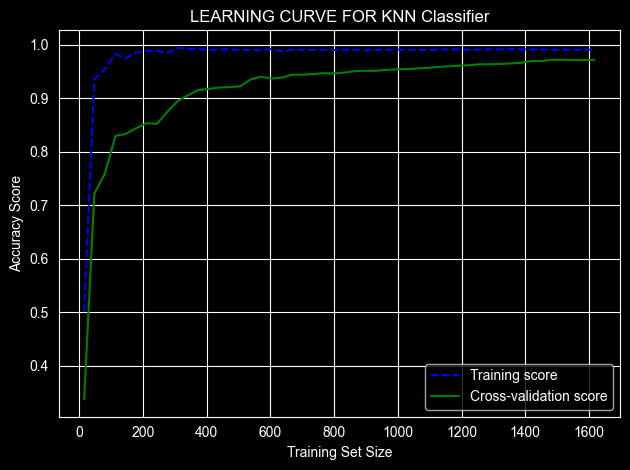

[[0.5        0.5        0.5        0.5        0.5        0.5
  0.5        0.5        0.5        0.5       ]
 [0.91666667 0.9375     0.9375     0.9375     0.9375     0.9375
  0.9375     0.9375     0.9375     0.9375    ]
 [0.98765432 0.95061728 0.95061728 0.95061728 0.95061728 0.95061728
  0.95061728 0.95061728 0.95061728 0.95061728]
 [0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
  0.98245614 0.98245614 0.98245614 0.98245614]
 [0.99315068 0.97260274 0.97260274 0.97260274 0.97260274 0.97260274
  0.97260274 0.97260274 0.97260274 0.97260274]
 [1.         0.98324022 0.98324022 0.98324022 0.98324022 0.98324022
  0.98324022 0.98324022 0.98324022 0.98324022]
 [0.99528302 0.96698113 0.99056604 0.99056604 0.99056604 0.99056604
  0.99056604 0.99056604 0.99056604 0.99056604]
 [0.99180328 0.96311475 0.99180328 0.99180328 0.99180328 0.99180328
  0.99180328 0.99180328 0.99180328 0.99180328]
 [0.98916968 0.96750903 0.98555957 0.98555957 0.98555957 0.98555957
  0.98555957 0.98555957

In [4]:
#Importing Required Libraries and Modules
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve

# Load data set
dataset = load_digits()

# X contains data and y contains labels
X, y = dataset.data, dataset.target

# Obtain scores from learning curve function
# cv is the number of folds while performing Cross Validation
sizes, training_scores, testing_scores = learning_curve(KNeighborsClassifier(), X, y, cv=10, scoring='accuracy', train_sizes=np.linspace(0.01, 1.0, 50))

# Mean and Standard Deviation of training scores
mean_training = np.mean(training_scores, axis=1)
Standard_Deviation_training = np.std(training_scores, axis=1)

# Mean and Standard Deviation of testing scores
mean_testing = np.mean(testing_scores, axis=1)
Standard_Deviation_testing = np.std(testing_scores, axis=1)

# dotted blue line is for training scores and green line is for cross-validation score
plt.plot(sizes, mean_training, '--', color="b",  label="Training score")
plt.plot(sizes, mean_testing, color="g", label="Cross-validation score")

# Drawing plot
plt.title("LEARNING CURVE FOR KNN Classifier")
plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(training_scores)
print(mean_training)
print(len(mean_training))